<div style="border: 2px solid #007ACC; background-color: #EAF4FF; padding: 10px; border-radius: 5px;">
<strong>💡 Note:</strong> You need a Google Earth Engine account to run this notebook.
</div>

# Sampling ERA5-Land hourly met data

This notebook demonstrates how to:

1. **Sample ERA5-Land hourly meteorology** from Google Earth Engine (GEE) over arbitrary geometries (points or polygons).
2. **Convert those sampled time series into ELM-ready meteorological files** using `dapper`.

A couple notes up front:

- When we say “ERA5” here, we specifically mean the **ERA5-Land Hourly** ImageCollection in Earth Engine: `ECMWF/ERA5_LAND/HOURLY`.
- `dapper` can write ELM MET files in two layouts:
  - **sites mode**: one output folder per geometry (one run per row)
  - **cellset mode**: one set of files representing a multi-cell “cellset” run

In this example, we'll build 1° x 1° grid cells around a few NGEE Arctic sites of interest as demonstration. We'll look at both `sites` and `cellset` modes. And we'll discuss some of the options and "behind the scenes" stuff.

## Setup
We'll handle imports, GEE initialization, and pathing up front.

- `OUT_ROOT` is where `dapper` will write your run outputs.
- `CSV_DIR` is where **you** will download the exported GEE CSV shards after GEE is done cranking them out. (More on this later.)
- Set the `project=` argument to **your** GEE project.


In [ ]:
import ee
import pandas as pd
import geopandas as gpd
from pathlib import Path
from shapely.geometry import Polygon

from dapper import Domain
from dapper import ERA5Adapter
from dapper import sample_e5lh
from dapper.config.metsources import era5
from dapper.met.exporter import Exporter

# A helper function to make sure we're pathing correctly
def find_repo_root(start=None, markers=("pyproject.toml", "setup.cfg", ".git")) -> Path:
    """Walk upward from start (default: cwd) until a repo marker is found."""
    p = Path(start or Path.cwd()).resolve()
    for parent in (p, *p.parents):
        if any((parent / m).exists() for m in markers):
            return parent
    raise FileNotFoundError(
        "Could not find dapper repo root. Set manually."
    )


In [16]:
# Things you MUST change
MY_GEE_PROJECT = 'ee-jonschwenk' # This corresponds to your GEE project name (the project must be registered with GEE already; see GEE setup docs)

# Things you CAN change
DAPPER_ROOT = find_repo_root() # If this fails, manually set to Path("where/dapper/is/on/your/machine")
OUT_ROOT = DAPPER_ROOT / 'docs' / 'data' / 'outputs' / 'era5-to-elm'   # this is where we'll store example outputs
RUN_NAME = "dapper_era5-to-elm"   # used for the output folder name + GEE job name
GDRIVE_FOLDER = "dapper_era5_exports"        # Google Drive folder name for the GEE tasks

# Don't change unless you need to
DATA_DIR = DAPPER_ROOT / 'docs' / 'data' / 'met_era5-to-elm'
CSV_DIR  = DATA_DIR / 'gee_shards'   # where you'll download the GEE exports

# Make sure OUT_ROOT and CSV_DIR exist
OUT_ROOT.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

# ---- Earth Engine init ----
# Use YOUR project here (do not use mine; it won't work for you)
ee.Initialize(project=MY_GEE_PROJECT)


## Build our domain

`dapper` needs a user-provided geometry table that has:

- a unique string identifier column (call it  `gid` for lower chance of problems, but its name can be specified)
- a geometry column (points or polygons)
- a geographic CRS (EPSG:4326)

If you want to run your own and already have a file (GeoPackage, shapefile, GeoJSON, …), point `GEOMS_PATH` at it. However, this notebook builds this table by selecting a few NGEE Arctic sites and building a grid cell (1°×1°) around them.

In [8]:
# Coordinates of NGEE Arctic sites
sites = {'tl27' : (-165.959, 64.735),
    'tl47' :  (-166.12778, 65.01896),
    'kg' : (-164.82771, 65.16185),
    'kfc' : (-164.65123, 65.45158),
    'cnl' : (-163.7181, 64.8541),
    'utq' :  (-156.65414, 71.31381),
    'tvc' : (-133.49919, 68.74207),
    'tfs' : (-149.59351, 68.62758),
    'abs' : (18.81545, 68.35418),
    'bs' : (11.835, 78.9325),
    'si' : (126.47446, 72.37004)}

# Create 1x1 degree box geometries around each point
geometries = []
gids = []
half_size = 0.5  # degrees

for gid, (lon, lat) in sites.items(): 
    # sanity checks
    assert -180 <= lon <= 180, f"{gid}: lon out of range: {lon}"
    assert -90  <= lat <= 90,  f"{gid}: lat out of range: {lat}"

    box = Polygon([
        (lon - half_size, lat - half_size),
        (lon + half_size, lat - half_size),
        (lon + half_size, lat + half_size),
        (lon - half_size, lat + half_size),
        (lon - half_size, lat - half_size),
    ])
    geometries.append(box)
    gids.append(gid)

# Create a GeoDataFrame - note that it must have a column called "gid" that provides a string ID for each geometry 
gdf = gpd.GeoDataFrame({'gid': gids, 'geometry': geometries}, crs="EPSG:4326")
print(gdf)

     gid                                           geometry
0   tl27  POLYGON ((-166.459 64.235, -165.459 64.235, -1...
1   tl47  POLYGON ((-166.62778 64.51896, -165.62778 64.5...
2     kg  POLYGON ((-165.32771 64.66185, -164.32771 64.6...
3    kfc  POLYGON ((-165.15123 64.95158, -164.15123 64.9...
4    cnl  POLYGON ((-164.2181 64.3541, -163.2181 64.3541...
5    utq  POLYGON ((-157.15414 70.81381, -156.15414 70.8...
6    tvc  POLYGON ((-133.99919 68.24207, -132.99919 68.2...
7    tfs  POLYGON ((-150.09351 68.12758, -149.09351 68.1...
8    abs  POLYGON ((18.31545 67.85418, 19.31545 67.85418...
9     bs  POLYGON ((11.335 78.4325, 12.335 78.4325, 12.3...
10    si  POLYGON ((125.97446 71.87004, 126.97446 71.870...


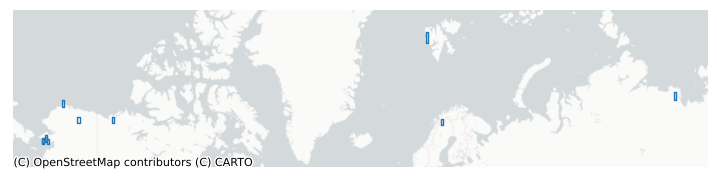

In [21]:
# If you want to visualize the grid cells:
import matplotlib.pyplot as plt
import contextily as ctx

# Contextily wants Web Mercator (EPSG:3857)
gdf_3857 = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))

# Plot grid cell outlines (no fill)
gdf_3857.boundary.plot(ax=ax, linewidth=1)

# Zoom to the domain with a little padding
minx, miny, maxx, maxy = gdf_3857.total_bounds
pad_x = (maxx - minx) * 0.05
pad_y = (maxy - miny) * 0.2
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y - 10000, maxy + pad_y)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()

## Create a `Domain`

The `Domain` class in `dapper` is needed to use pretty much any of `dapper`'s functionality. It ensures consistency across functions.

When we instantiate a `Domain`, we have some choices to make. Right now, the main one is: do we want outputs in `sites` or `cellset`? If we one "one set of output files per row in our GeoDataFrame", we would select `sites`. If we want "one set of output files for the entire GeoDataFrame", we'd choose `cellset`. Here we will choose `cellset`, but you can easily re-run all the commands here using `sites`.

In [ ]:
domain = Domain.from_provided(
    gdf,
    name=RUN_NAME,
    mode="cellset",
    id_col="gid",
    path_out=OUT_ROOT,
)
domain.gdf # Our GeoDataFrame is stored in the Domain class (along with a few others that dapper computes--feel free to explore them! use dir(domain) to see the contents of the class.)


,gid,geometry,lon,lat
0,tl27,"POLYGON ((-166.459 64.235, -165.459 64.235, -1...",-165.95900,64.73500
1,tl47,"POLYGON ((-166.62778 64.51896, -165.62778 64.5...",-166.12778,65.01896
2,kg,"POLYGON ((-165.32771 64.66185, -164.32771 64.6...",-164.82771,65.16185
3,kfc,"POLYGON ((-165.15123 64.95158, -164.15123 64.9...",-164.65123,65.45158
4,cnl,"POLYGON ((-164.2181 64.3541, -163.2181 64.3541...",-163.71810,64.85410
5,utq,"POLYGON ((-157.15414 70.81381, -156.15414 70.8...",-156.65414,71.31381
6,tvc,"POLYGON ((-133.99919 68.24207, -132.99919 68.2...",-133.49919,68.74207
7,tfs,"POLYGON ((-150.09351 68.12758, -149.09351 68.1...",-149.59351,68.62758
8,abs,"POLYGON ((18.31545 67.85418, 19.31545 67.85418...",18.81545,68.35418
9,bs,"POLYGON ((11.335 78.4325, 12.335 78.4325, 12.3...",11.83500,78.93250


## Sample ERA5
> **Note:** You can skip this step as the exported shards have been included with this notebook, but it's important to understand how this works for you own use.

For ERA5-Land data, we use Google Earth Engine to sample. GEE's cloud infrastructre and API make it easy to scale analyses without using any of your local CPU.

`sample_e5lh(params)` does two things:

1. Submits one or more **Google Drive export tasks** (time is chunked into multi-year batches depending on your job size).
2. Returns a **Domain describing the sampling locations** used by GEE (after any necessary “pixel-center” adjustments). You usually don't need this information.

Important implementation detail:

- ERA5-Land Hourly has ~11 km native resolution. **Small polygons can miss pixel centers**, which can yield empty samples.
- `sample_e5lh` guards against this by ensuring each geometry includes at least one native pixel center (and may fall back to a representative point when needed).

In order to make sure we're grabbing the portions of the ERA5 data that we want, we need to build a dictionary of parameters that defines some of our sampling decisions. In this section, we'll walk through some of these parameters and some possible choices and implications.


### Set up our GEE request via a dictionary of parameters
In order to make sure we're grabbing the portions of the ERA5 data that we want, we need to build a dictionary of parameters that defines some of our sampling decisions. In this section, we'll walk through some of these parameters and some possible choices and implications.

#### 1. Select relevant bands
We need to provide the specific ERA5-Land hourly bands we want to sample. If you just want the ELM-required bands, there is a convenient method to request just those: `elm`. You can see the required bands with the following:

In [13]:
print(era5.REQUIRED_RAW_BANDS)

['temperature_2m', 'dewpoint_temperature_2m', 'surface_pressure', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'surface_solar_radiation_downwards_hourly', 'surface_thermal_radiation_downwards_hourly', 'total_precipitation_hourly']


This is the minimal set of bands you'll need to compute the 8 meterologic variables we'll prepare for ELM intake. You'll see when we actually define the `params` dictionary below that there's a shortcut here.

#### 2. Select scale
We can now specify a `gee_scale`. This is the resolution in meters over which GEE should sample the base ERA5-Land hourly data at to perform *spatial averaging* over (multi)polygons. If you're sampling points, this scale should just be `native` which will use the ERA5-Land hourly's native resolution of ~11km, but if you're running bigger polygons or lots of them, you might want to choose a coarser scale to reduce GEE Task runtimes. See [this documentation](https://developers.google.com/earth-engine/guides/scale#:~:text=The%20lowest%20level%20of%20the,within%20a%20256x256%20pixel%20tile.) if you have questions about scale implications. We'll just stick with `native` for this test.


#### 3. Select batch size
We have a parameter that adjusts how big our batch size (how many years of imagery should GEE process per task) should be. This parameter is called `gee_years_per_task`, and refers to how many ERA5-Land hourly years each Task sent to GEE should cover. In general, the more geometries you are sampling, the lower you want this number to be. The default of 5 should work OK for a few hundred Point geometries, but if you're doing thousands of Point geometries or larger 2-D geometries you might want to lower it to 1 or 2. Note that there is an optimal number for this parameter in terms of speed of output, but it's basically unknowable. On your end, tt depends on the size of your job (number of geometries and length of time you sample). On the GEE end (unknowable exactly), it depends on current server loads, task prioritization, and memory constraints. **In general, I have found it is better to run more, smaller Tasks on GEE as opposed to larger, fewer ones.** If your Tasks are too large, they also run the risk of *failure*, in which case GEE will retry them (at a cost of lost time to you and potential more *failure*). We set it to 1 in this example to prove that post-processing batching works just fine :) 

#### 4. Specify geometries
We already constructed `domain` which contains our polygons to sample. We will feed this directly as part of our `params` dictionary. **However**, if you have many polygons, or if they have lots of vertices, this method (directly passing a `Domain` or `GeoDataFrame`) will fail as there is a size limit on geometries that you're able to pass directly from the Python API to GEE. Instead, you will need to upload your shapefile to GEE as an Asset. This is very easy to do; see [this documentation](https://developers.google.com/earth-engine/guides/manage_assets#code-editor_1). Once you've uploaded it, you can now just provide a string to this parameter that represents the path to the asset--for example, `'projects/ee-jonschwenk/assets/AK_temp_20230530'`. Again, here we will just use our `domain`. **Remember that your geometries must have a `gid` field containing unique identifiers for each geometry feature.** 

#### 5. Select time range
The ERA5 data we'll be sampling is hourly, and it spans from 1950-01-01 to near-present-day. If you want all available data, use `2100-01-01` as your `end_date`. 

#### 6. Other stuff
See the next block of code for some other intuitive parameters you need to specify related to naming the Tasks and where to store the outputs.

Ok, now we can build our `params` dictionary and spin up some Tasks. I've used comments below to explain what each parameter does in addition to the above explanations. Note that there are more parameters available than what's shown here; this is just a nearly-minimal set you'll need to define.

In [12]:
params = {
    # time range (YYYY-mm-dd) - here we sample a short time window for example purposes
    "start_date": "2019-01-01", # 1950-01-01 is earliest available for ERA5-Land hourly
    "end_date":   "2021-12-31", # Set to 2100-01-01 for all available data

    # geometries: we simply pass in our Domain instance
    "geometries": domain,

    # which bands/variables?
    # - "elm"  : the set of ERA5 variables dapper expects for ELM conversion
    # - "all"  : everything in the collection (there are lots, so be careful with this one)
    # - list   : explicit band names in a list
    "gee_bands": "elm", 

    # scale: "native" is recommended; you can set to larger if you're doing large domains (like we are). We'll leave it at native (~11 km for this dataset) for now.
    "gee_scale": "native",

    # chunking for Drive exports (years per task)
    "gee_years_per_task": 1,

    # Drive export settings
    "gdrive_folder": GDRIVE_FOLDER,
    "job_name": RUN_NAME,
}

# This submits Google Drive export tasks.
# If you want to sanity-check your params without starting tasks, set skip_tasks=True.
_ = sample_e5lh(params, domain_name=RUN_NAME, skip_tasks=False)

Your request will be executed as 3 Tasks in Google Earth Engine.
GEE Export task submitted: dapper_era5-to-elm_2019-01-01_2020-01-01
GEE Export task submitted: dapper_era5-to-elm_2020-01-01_2021-01-01
GEE Export task submitted: dapper_era5-to-elm_2021-01-01_2021-12-31
All export tasks started. Check Google Drive or Task Status in the Javascript Editor for completion.


> **Tip!** If you accidentally sent Tasks to GEE but didn't mean to, you can just call `dapper.integrations.earthengine.gee_utils.kill_all_tasks()` which will cancel all Tasks in your queue.

### Now we wait.
We've sent some Tasks (5 of them) to Google Earth Engine. You can check on their state using the [GEE Javascript code editor](http://code.earthengine.google.com) by clicking the `Tasks` tab in the upper-right panel. Eventually your Tasks will finish, and your csvs will show up where you told GEE to put them: `GDRIVE_FOLDER`.

The amount of time you wait totally depends on your job size and GEE's current load. I am able to have 4 Tasks running at once on GEE--any more and they wait for one of the 4 to finish first. GEE controls these things. In general, unless you're running something enormous, it shouldn't take more than a few hours, and can take as little as a few minutes. Also note that the time of day may impact the runtimes, as GEE servers get hit more during Mon-Fri, 9-5 USA. I ran the above on Saturday and it took 6 minutes to finish all 4 Tasks.

### **Important!** 
Once all Tasks are complete, you must move all the files from your GDrive to `CSV_DIR` on your machine. Make sure there is nothing else in this folder besides all the files that were exported from this Job. The easiest and fastest way to move files from GDrive to local is with the Google Drive app, but you can also just download from the browser (it's annoying this way because GDrive wants to zip everything which can take awhile if you have lots of files).

## Exporting to ELM-ready formats
At this point, you should have populated `CSV_DIR` with all the `.csv` shards exported from your GEE Tasks. **`CSV_DIR` should have no other files in it besides these.** Note that for this notebook, these files have already been provided as examples.

### A. Exporting 1-hr met data
Once the raw data have been downloaded from GEE, `dapper` can resample it to whatever time resolution you want. This is fast. We can re-export at different time resolutions as desired (no need to re-export the "raw" GEE shards again.)

`dapper` uses custom `Adapter` classes that allow it to export different types of met data. As of now, only ERA5 and Flux tower data are supported, but it's pretty easy to add more (open an Issue).

The `Exporter` interface is fairly simple:

- `src_path` points at the directory containing your downloaded CSV shards
- `domain` controls the output layout (sites vs cellset)
- `Exporter.run()` writes ELM-ready NetCDF files (and handles parquet staging internally)

You can also:
- change `dtime_resolution_hrs` to aggregate (e.g., 3-hourly forcing from hourly ERA5)
- pass `include_vars` / `exclude_vars` if you only want a subset of bands
- pass `append_attrs` to add custom global attributes to the output files


In [32]:
exp = Exporter(
    adapter=ERA5Adapter(),
    src_path=CSV_DIR,
    out_dir = OUT_ROOT / '1_hr_cellset', # Specify where to write the output files - they will be in a directory called 'MET'
    domain=domain,             
    calendar="noleap",         # ignore leap days
    dtime_resolution_hrs=1,    # I think this can even handle 0.5 (30 minute data) but you'd better check the output as that requires interpolation
    append_attrs={
        "note": "Exported with dapper (ERA5-Land Hourly via GEE)",
        "gee_collection": "ECMWF/ERA5_LAND/HOURLY",
    },
)
exp.run()

Processing file 1 of 3: X:\Research\NGEE Arctic\dapper\docs\data\met_era5-to-elm\gee_shards\dapper_era5-to-elm_2019-01-01_2020-01-01.csv
Processing file 2 of 3: X:\Research\NGEE Arctic\dapper\docs\data\met_era5-to-elm\gee_shards\dapper_era5-to-elm_2020-01-01_2021-01-01.csv
Processing file 3 of 3: X:\Research\NGEE Arctic\dapper\docs\data\met_era5-to-elm\gee_shards\dapper_era5-to-elm_2021-01-01_2021-12-31.csv
cellset export complete.


### A quick note on “raw shards” vs “ELM-ready” outputs

- The **raw** outputs are the CSV shards you downloaded from Google Drive (`CSV_DIR`). These are useful for debugging and for one-off checks.
- During `Exporter.run()`, `dapper` also stages **per-site parquet** under a temporary directory inside your run folder (look for `.dapper_tmp/met_parquet`). You can ignore this most of the time — it’s mainly there to make the export pipeline fast and repeatable.
- The final products you typically point ELM to are the NetCDF files under each site’s `MET/` directory.


### What got written?

For **sites mode**, you should see something like:

- `OUT_ROOT / 1_hr_cellset /  MET / TBOT.nc`
- … etc
- plus a `zone_mappings.txt` in the MET directory.


In [23]:
# A quick directory peek (first few paths)
out_dir = OUT_ROOT / '1_hr_cellset'
sorted([p.relative_to(out_dir) for p in out_dir.rglob("*")])[:40]


[WindowsPath('.dapper_tmp'),
 WindowsPath('MET'),
 WindowsPath('MET/FLDS.nc'),
 WindowsPath('MET/FSDS.nc'),
 WindowsPath('MET/PRECTmms.nc'),
 WindowsPath('MET/PSRF.nc'),
 WindowsPath('MET/QBOT.nc'),
 WindowsPath('MET/TBOT.nc'),
 WindowsPath('MET/WIND.nc'),
 WindowsPath('MET/zone_mappings.txt')]

Note that if you are running in `sites` mode (here we're using `cellset`), you will get a site directory for each site that contains the above folder/file structure.

For completeness, here we'll also export a 24 hour temporal resolution. It's really easy--we only have to adjust the `dtime_resolution_hrs` parameter (and the `out_dir`).

In [25]:
exp24 = Exporter(
    adapter=ERA5Adapter(),
    src_path=CSV_DIR,
    out_dir = OUT_ROOT / '24_hr_cellset', # Specify where to write the output files - they will be in a directory called 'MET'
    domain=domain,             
    calendar="noleap",         # ignore leap days
    dtime_resolution_hrs=24,    # easy-peasy
    append_attrs={
        "note": "Exported with dapper (ERA5-Land Hourly via GEE)",
        "gee_collection": "ECMWF/ERA5_LAND/HOURLY",
    },
)
exp24.run()

Processing file 1 of 3: X:\Research\NGEE Arctic\dapper\docs\data\met_era5-to-elm\gee_shards\dapper_era5-to-elm_2019-01-01_2020-01-01.csv
Processing file 2 of 3: X:\Research\NGEE Arctic\dapper\docs\data\met_era5-to-elm\gee_shards\dapper_era5-to-elm_2020-01-01_2021-01-01.csv
Processing file 3 of 3: X:\Research\NGEE Arctic\dapper\docs\data\met_era5-to-elm\gee_shards\dapper_era5-to-elm_2021-01-01_2021-12-31.csv
cellset export complete.


## Quick validation

The problem with tools like `dapper` is that users may trust them a bit too much.
It’s worth taking a few minutes here to sanity-check the outputs, and you should **always** do this as a user.

`make_quicklooks` generates a small set of plots (per-site, across a handful of variables) that can catch:
- missing data
- unit mistakes
- time alignment issues
- obviously “wrong-looking” seasonal cycles


In [ ]:
from dapper.met import validation
plot_gids = ['tl27', 'si'] # Select whichever site gids you want to pull from the exported met files
validation.make_quicklooks(exp, gids=plot_gids) # For the 1-hour
validation.make_quicklooks(exp24, gids=plot_gids) # For the 24-hour

quicklooks written to X:\Research\NGEE Arctic\dapper\docs\data\outputs\era5-to-elm\1_hr_cellset\quicklooks
quicklooks written to X:\Research\NGEE Arctic\dapper\docs\data\outputs\era5-to-elm\24_hr_cellset\quicklooks


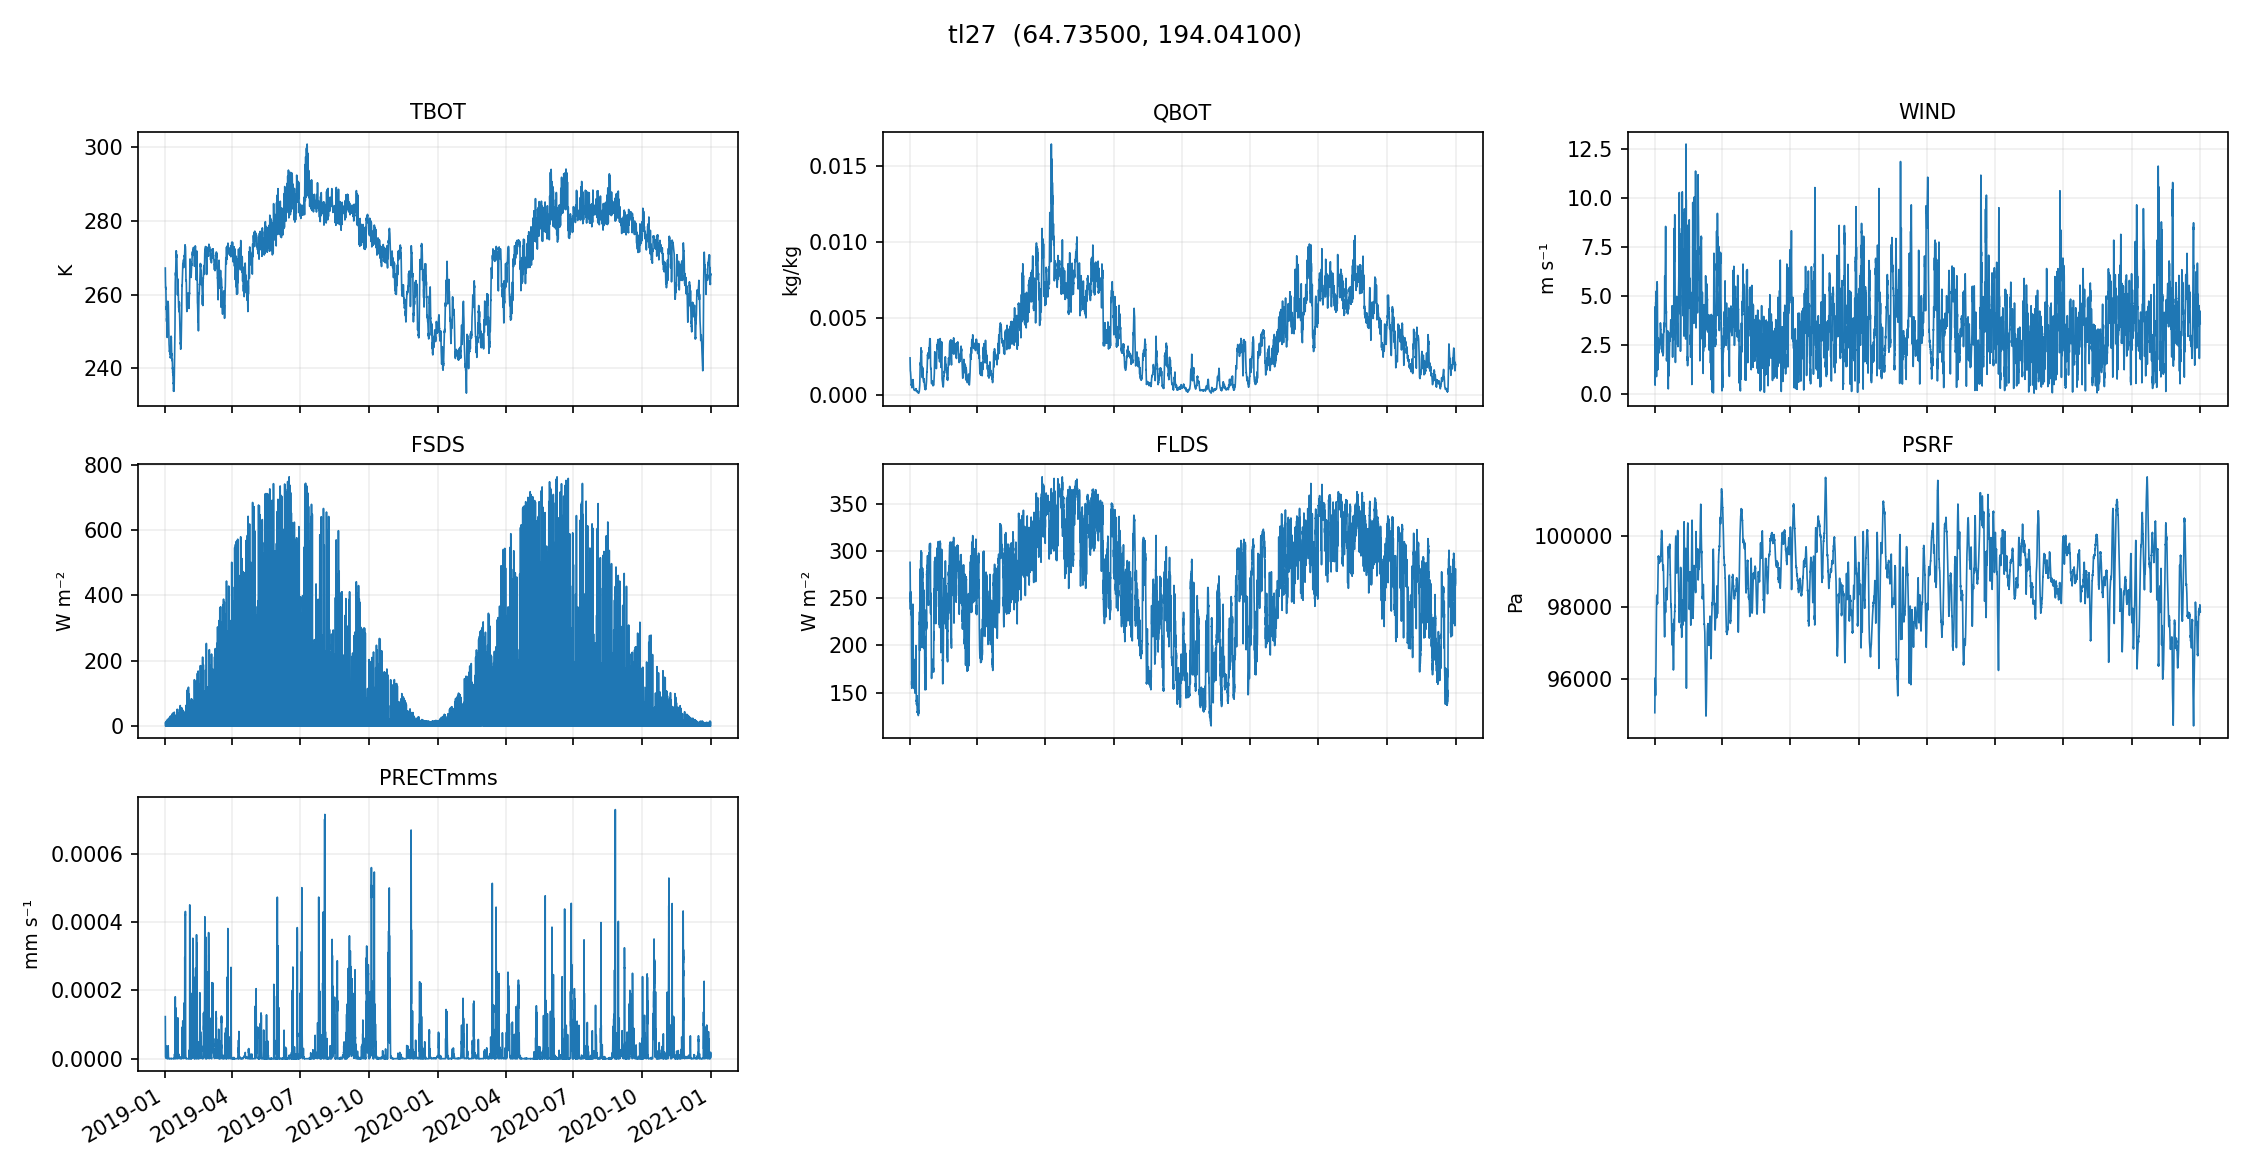

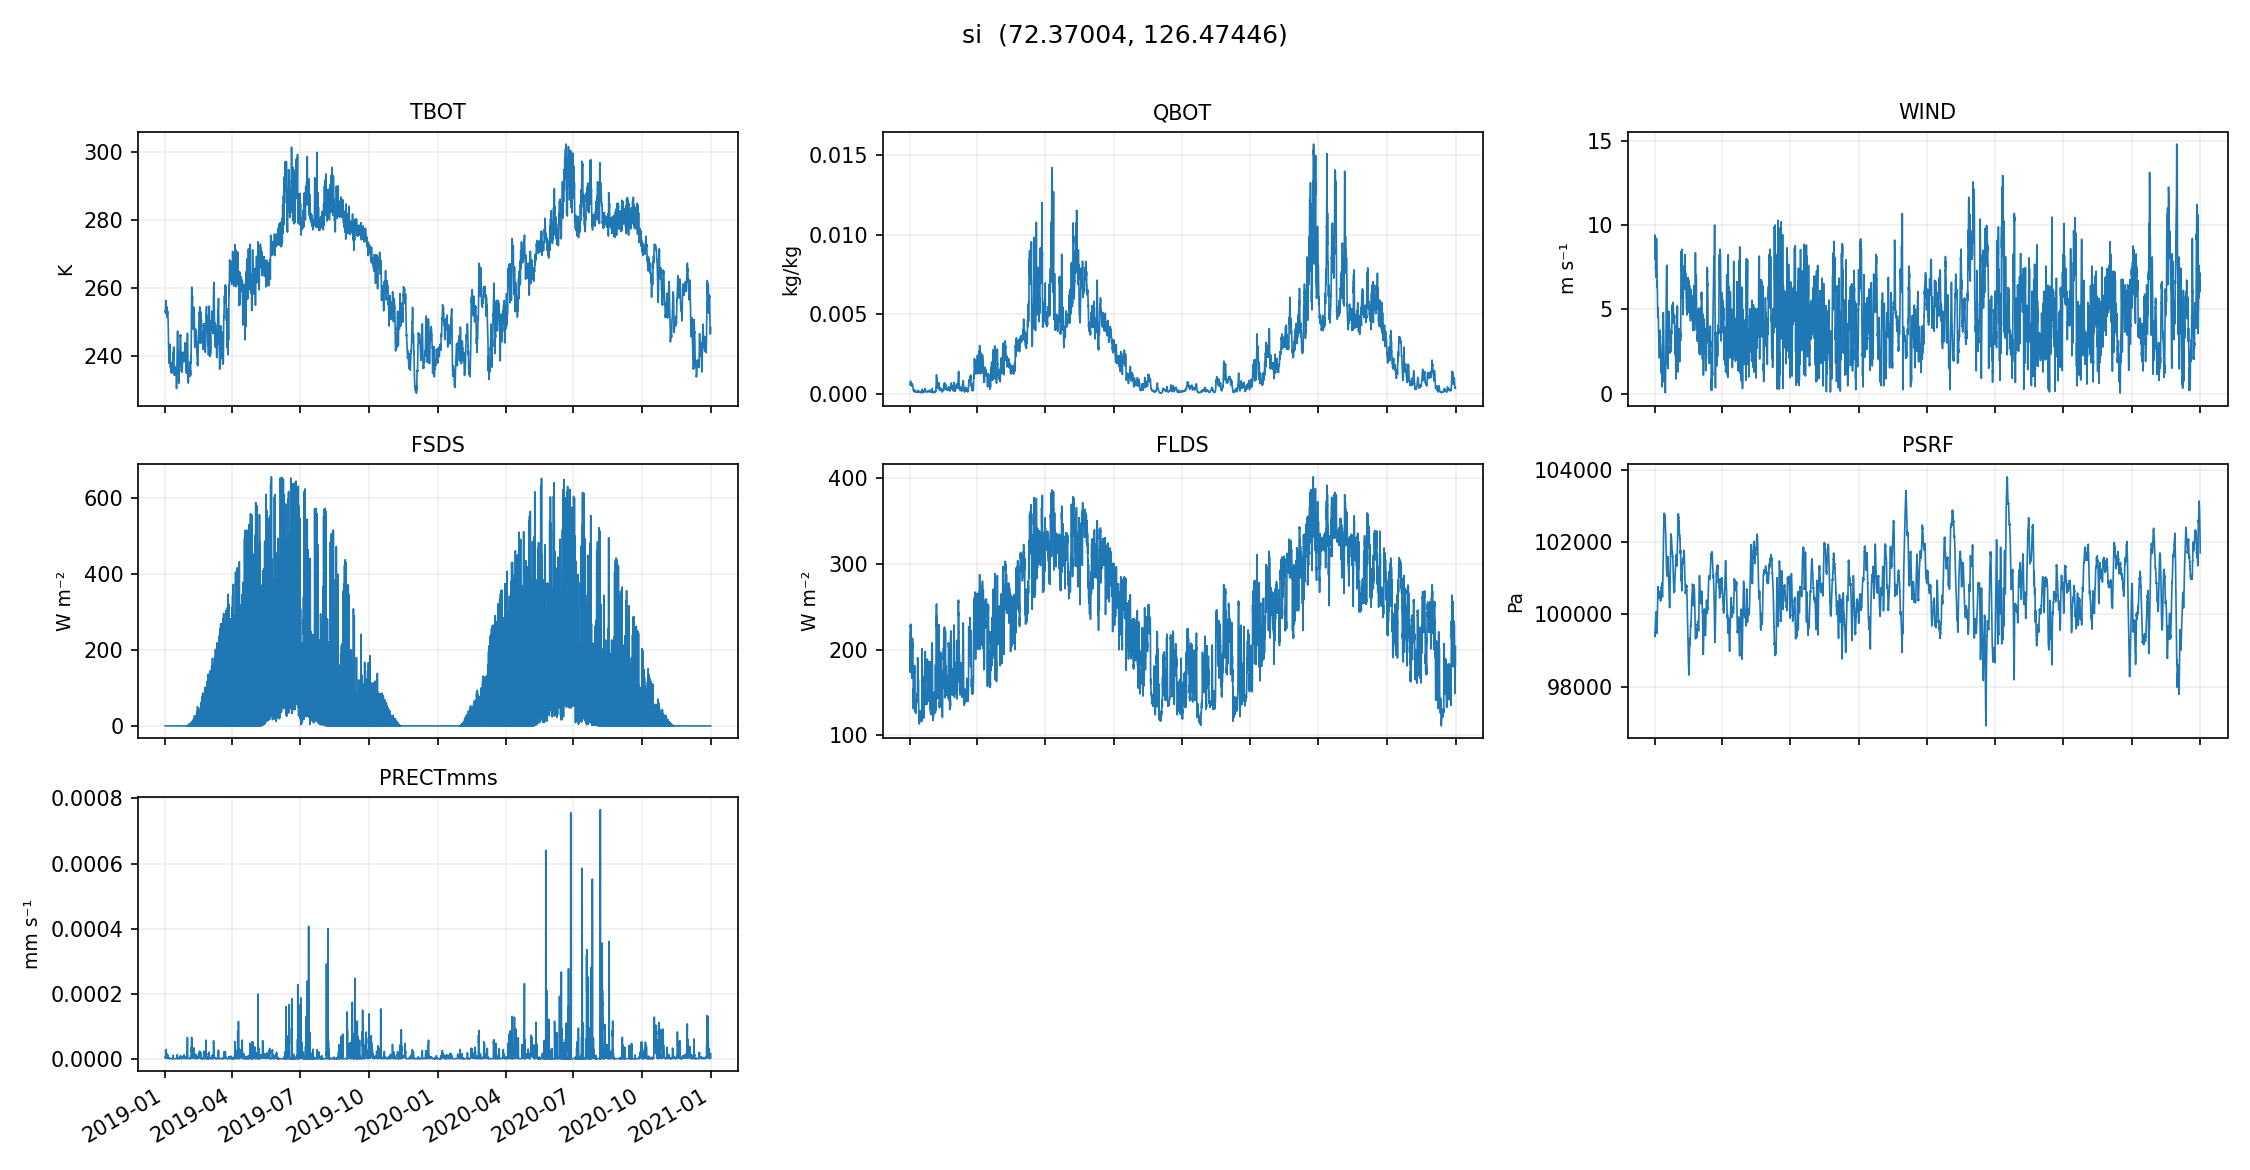

In [40]:
# You can just look at the generated images on your hard drive; we'll plot them here for completeness
from IPython.display import Image, display
# Once they're exported, we can plot them:
quicklooks_path = OUT_ROOT / '1_hr_cellset' / 'quicklooks' # If you want to plot the 24-hour, you can change '1_hr_cellset' to '24_hr_cellset'
for gid in plot_gids:
    image_file = str(quicklooks_path / Path(gid + '.png'))
    display(Image(filename=image_file))


These plots are meant to be *fast and dirty* checks — they’re not a replacement for deeper validation,
but they’re a really nice early warning system if something went sideways in sampling, downloading,
or exporting.
